In [1]:
import os
os.chdir("..") # Ek folder piche jane ke liye
print(os.getcwd()) # Check karein ke ab path 'psl_ai_platform' par hai ya nahi

c:\Users\User\Desktop\psl_ai_platform


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data/processed/ball_by_ball/psl_ball_by_ball_clean.csv")
df.head()

,match_id,innings_number,batting_team,over,ball,batter,bowler,non_striker,runs_batter,runs_extras,...,fielders_involved,match_date,city,venue,team1,team2,toss_winner,toss_decision,phase,ball_id
0,959175,1,Islamabad United,0,1,NaN,Anwar Ali,Sharjeel Khan,0,0,...,NaN,2016-02-04,NaN,Dubai International Cricket Stadium,Islamabad United,Quetta Gladiators,Quetta Gladiators,field,powerplay,0.1
1,959175,1,Islamabad United,0,2,NaN,Anwar Ali,Sharjeel Khan,0,0,...,NaN,2016-02-04,NaN,Dubai International Cricket Stadium,Islamabad United,Quetta Gladiators,Quetta Gladiators,field,powerplay,0.2
2,959175,1,Islamabad United,0,3,NaN,Anwar Ali,Sharjeel Khan,0,0,...,NaN,2016-02-04,NaN,Dubai International Cricket Stadium,Islamabad United,Quetta Gladiators,Quetta Gladiators,field,powerplay,0.3
3,959175,1,Islamabad United,0,4,NaN,Anwar Ali,Sharjeel Khan,0,0,...,NaN,2016-02-04,NaN,Dubai International Cricket Stadium,Islamabad United,Quetta Gladiators,Quetta Gladiators,field,powerplay,0.4
4,959175,1,Islamabad United,0,5,NaN,Anwar Ali,Sharjeel Khan,0,0,...,NaN,2016-02-04,NaN,Dubai International Cricket Stadium,Islamabad United,Quetta Gladiators,Quetta Gladiators,field,powerplay,0.5


In [4]:
phase_summary = (
    df.groupby(["batter", "phase"])
    .agg(
        balls_faced=("batter", "count"),
        runs_scored=("runs_batter", "sum"),
        dismissals=("player_out", lambda x: x.notna().sum()),
        matches=("match_id", "nunique"),
    )
    .reset_index()
)

phase_summary["strike_rate"] = (
    phase_summary["runs_scored"] / phase_summary["balls_faced"] * 100
).round(2)

phase_summary.head()

,batter,phase,balls_faced,runs_scored,dismissals,matches,strike_rate


In [5]:
selected_batters = ["Babar Azam", "Mohammad Rizwan", "Fakhar Zaman"]
selected_df = phase_summary[phase_summary["batter"].isin(selected_batters)]
selected_df


,batter,phase,balls_faced,runs_scored,dismissals,matches,strike_rate


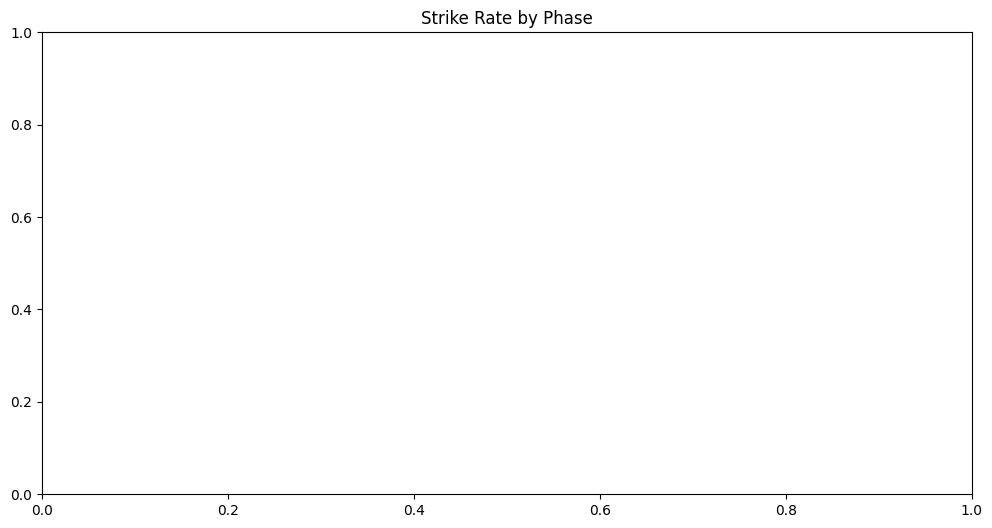

In [6]:
plt.figure(figsize=(12, 6))
sns.barplot(data=selected_df, x="phase", y="strike_rate", hue="batter")
plt.title("Strike Rate by Phase")
plt.show()

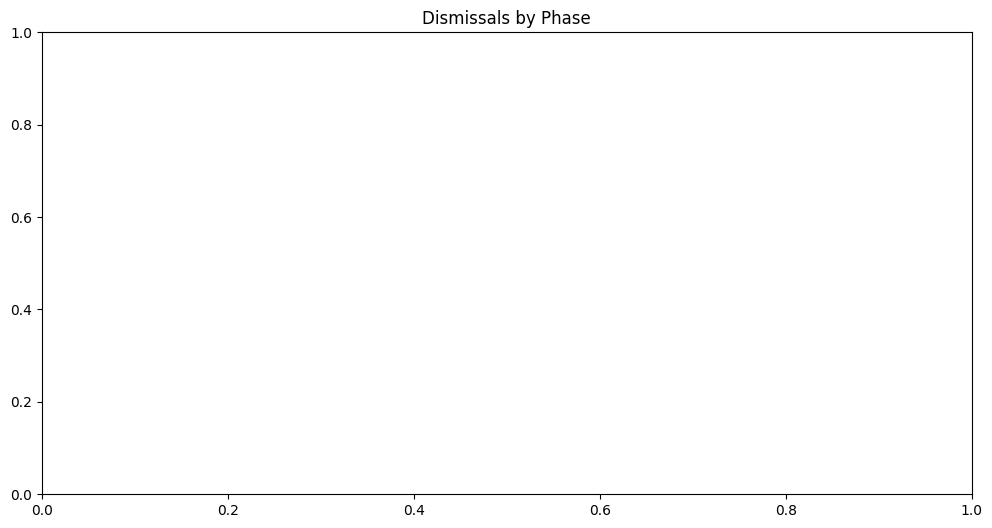

In [7]:
plt.figure(figsize=(12, 6))
sns.barplot(data=selected_df, x="phase", y="dismissals", hue="batter")
plt.title("Dismissals by Phase")
plt.show()

In [8]:
phase_summary.sort_values("strike_rate").head(20)

,batter,phase,balls_faced,runs_scored,dismissals,matches,strike_rate


In [9]:
phase_summary.sort_values("dismissals", ascending=False).head(20)

,batter,phase,balls_faced,runs_scored,dismissals,matches,strike_rate
